# Data Rexploration of Common Platform Enumeration (CPE)

* Name: Shinhyuk Park
* CID: 81424121
* Email: spark43@angelo.edu

---

## 1. What is CPE?

**Common platform enumeration (CPE)** is a standardized method used to identify and describe software, hardware, and firmware in a consistent format. It is part of the broader SCAP (security content automation protocol) suite of specifications developed by NIST (national institute of standards and technology). In simple terms, CPE refers to a standardized naming system for IT products and platforms. It helps in identifying software, hardware and operating systems that may be affected by certain vulnerabilities.

A CPE name (also called a "CPE URI" or "CPE string") follows a well-defined structure:

Cpe:2.3:[part]:[vendor]:[product]:[version]:[update]:[edition]:[language]:[sw_edition]:[target_sw]:[target_hw]:[other]
   
   - Part: defines whether the cpe refers to an application (`a`), operating system (`o`), or hardware (`h`).
   - Vendor: the name of the product’s vendor or manufacturer.
   - Product: the name of the product (e.g., Software, OS).
   - Version: the specific version of the product.
   - Update: any update or patch version of the product.
   - Edition: specific editions (e.g., Enterprise or professional).
   - Language: defines the product’s language (optional).
   - Other fields: additional, more specific attributes such as the software edition, target software, or hardware.


---

## 2. Neo4j Database Connection Using Python Driver

This code connects to a Neo4j database using the Python Neo4j driver, with authentication details provided (URI, username, and password). The main function, run_query, takes a Cypher query and optional parameters, executes the query in a session with the database, and returns the results as a list of dictionaries.

In [1]:
from neo4j import GraphDatabase
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

uri = "bolt://localhost:7687"
username = "neo4j"
password = "abcd90909090"

driver = GraphDatabase.driver(uri, auth=(username, password))

def run_query(query, parameters=None):
    with driver.session() as session:
        result = session.run(query, parameters)
        return [record.data() for record in result]

ModuleNotFoundError: No module named 'neo4j'


---
## 3. Rexploration of CPE

### Number of nodes and relationships

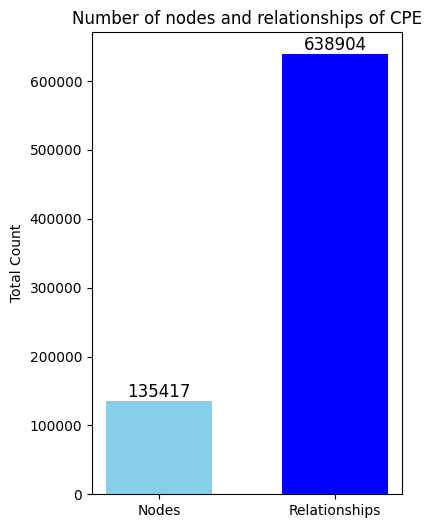

In [ ]:
# Total number of CPE
query = """
MATCH (c:UcoexCPE)
RETURN count(c) AS CPE
"""
params = {}

records = run_query(query, parameters=params)

count = records[0]['CPE']

# Total number of relationship regarding CPE
query = """
MATCH (c:UcoexCPE)-[r]-(t)
RETURN count(r) AS Relationship
"""
params = {}

records = run_query(query, parameters=params)

relationship_count = records[0]['Relationship']

# Bar graph to show the result
plt.figure(figsize=(4, 6))

plt.bar(['Nodes', 'Relationships'], [count, relationship_count], color=['skyblue', 'blue'], width=0.6)
plt.ylabel('Total Count')
plt.title(f'Number of nodes and relationships of CPE')
plt.text(0, count + 5, str(count), ha='center', va='bottom', fontsize=12)
plt.text(1, relationship_count + 5, str(relationship_count), ha='center', va='bottom', fontsize=12)
plt.show()

### List of node types and relationships

* List of properties

    1. **cpeName**:
    This is the Common Platform Enumeration (CPE) name identifier
    It follows the CPE naming format (e.g., "cpe:2.3:a:microsoft:windows:10::::::::")
    Used to uniquely identify a specific product/software version

    2. **cpeNameId**:
    A unique identifier for the CPE entry
    Used to reference the CPE in the NVD database
    Helps in tracking and linking CPE entries

    3. **dictionary_found**:
    A boolean flag indicating whether the CPE was found in the CPE dictionary database
    True if the CPE exists in the local SQLite database
    False if the CPE was not found in the dictionary

    4. **lastModified**:
    Timestamp indicating when the CPE entry was last updated
    Format: ISO 8601 datetime (e.g., "2024-03-20T10:30:00.000")
    Used to track the freshness of CPE data

    5. **titles**:
    A dictionary containing language-keyed titles for the CPE
    Format: {"lang": "title"}
    Contains human-readable names for the product in different languages
    Stored as JSON in the database

    6. **uri**:
    The Uniform Resource Identifier for the CPE
    In the mapping file, it's constructed using the template: http://example.com/ucoex#{cpeName}
    Used to create unique RDF resources for each CPE in the knowledge graph



* CPEs that are included in the NVD CPE dictionary.

In [ ]:
query = """
MATCH (c:UcoexCPE)
WHERE c.dictionary_found = true
UNWIND keys(c) AS PropertyName
RETURN PropertyName, apoc.meta.type(c[PropertyName]) AS PropertyType
LIMIT 6
"""
params = {}

records = run_query(query, parameters=params)

df_properties = pd.DataFrame(records)
df_properties

,PropertyName,PropertyType
0,lastModified,LocalDateTime
1,cpeNameId,STRING
2,cpeName,STRING
3,dictionary_found,BOOLEAN
4,uri,STRING
5,titles,STRING


* CPEs that are **not** included in the NVD CPE dictionary.

In [ ]:
query = """
MATCH (c:UcoexCPE)
WHERE c.dictionary_found = false
UNWIND keys(c) AS PropertyName
RETURN PropertyName, apoc.meta.type(c[PropertyName]) AS PropertyType
LIMIT 3
"""
params = {}

records = run_query(query, parameters=params)

df_properties = pd.DataFrame(records)
df_properties

,PropertyName,PropertyType
0,cpeName,STRING
1,dictionary_found,BOOLEAN
2,uri,STRING


### Distribution of relationship regarding 'CPE'

In [ ]:
query = """
MATCH (from:UcoexCPE)-[rel]-(to)
RETURN DISTINCT labels(from) AS From, type(rel) AS Relationship, labels(to) AS To, count(rel) AS Count
"""
params = {}

records = run_query(query, parameters=params)

df_relationships = pd.DataFrame(records)
df_relationships

,From,Relationship,To,Count
0,"[Resource, UcoexCPE]",UCOEXHASCPE,"[Resource, UcoCVE]",638904


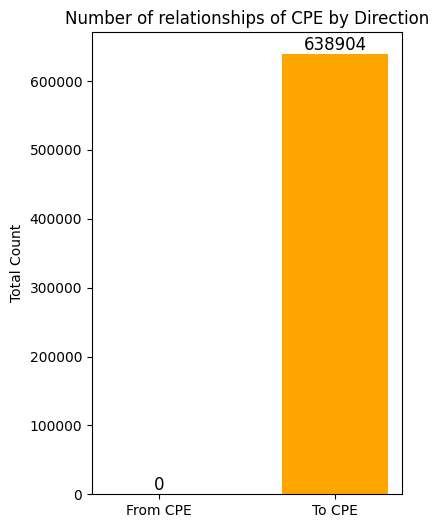

In [ ]:
# Total number of relationship emeging from CPE
query = """
MATCH (c:UcoexCPE)-[r]->(target)
RETURN count(r) AS Relationship
"""
params = {}

records = run_query(query, parameters=params)

total_rela_from_CPE = records[0]['Relationship']

# Total number of relationships going to CPE
query = """
MATCH (c:UcoexCPE)<-[r]-(target)
RETURN count(r) AS Relationship
"""
params = {}

records = run_query(query, parameters=params)

total_rela_to_CPE = records[0]['Relationship']

# Bar graph to show the result
plt.figure(figsize=(4, 6))

plt.bar(['From CPE', 'To CPE'], [total_rela_from_CPE, total_rela_to_CPE], color=['skyblue', 'orange'], width=0.6)
plt.ylabel('Total Count')
plt.title(f'Number of relationships of CPE by Direction')
plt.text(0, total_rela_from_CPE + 5, str(total_rela_from_CPE), ha='center', va='bottom', fontsize=12)
plt.text(1, total_rela_to_CPE + 5, str(total_rela_to_CPE), ha='center', va='bottom', fontsize=12)
plt.show()

### CPE Product Distribution

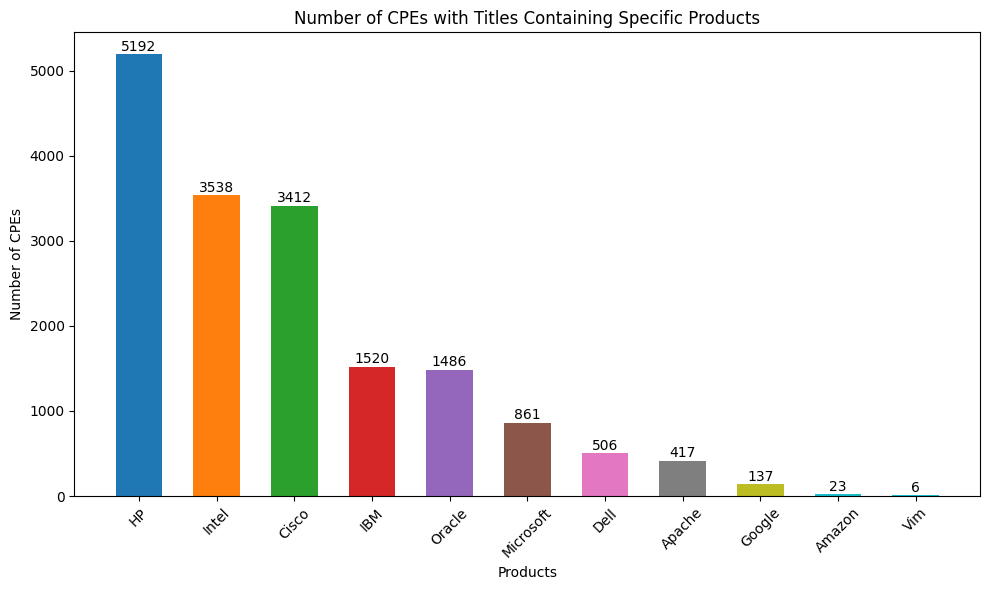

In [ ]:
keywords = ['Cisco', 'HP', 'Microsoft', 'Intel', 'IBM', 'Apache', 'Vim', 'Google', 'Oracle', 'Dell', 'Amazon']
counts = []

for keyword in keywords:
    query = f"""
    MATCH (c:UcoexCPE)
    WHERE c.titles CONTAINS '{keyword}'
    RETURN count(c) AS Count
    """
    params = {}
    records = run_query(query, parameters=params)
    counts.append(records[0]['Count'])

sorted_data = sorted(zip(counts, keywords), reverse=True)
sorted_counts, sorted_keywords = zip(*sorted_data)

colors = plt.cm.tab10(range(len(sorted_keywords)))

plt.figure(figsize=(10, 6))
plt.bar(sorted_keywords, sorted_counts, color=colors, width=0.6)
plt.xlabel('Products')
plt.ylabel('Number of CPEs')
plt.title('Number of CPEs with Titles Containing Specific Products')
plt.xticks(rotation=45)

for i, count in enumerate(sorted_counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

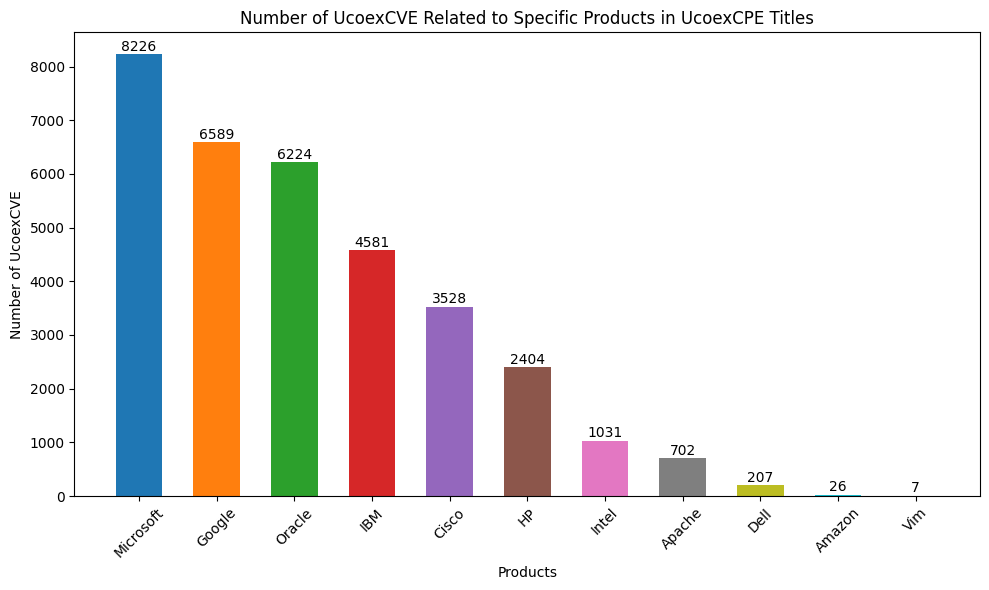

In [ ]:
keywords = ['Cisco', 'HP', 'Microsoft', 'Intel', 'IBM', 'Apache', 'Vim', 'Google', 'Oracle', 'Dell', 'Amazon']
counts = []

for keyword in keywords:
    query = f"""
    MATCH (c:UcoexCPE)-[r]-(v:UcoCVE)
    WHERE c.titles CONTAINS '{keyword}'
    RETURN count(DISTINCT v) AS Count
    """
    params = {}
    records = run_query(query, parameters=params)
    counts.append(records[0]['Count'])

sorted_data = sorted(zip(counts, keywords), reverse=True)
sorted_counts, sorted_keywords = zip(*sorted_data)

colors = plt.cm.tab10(range(len(sorted_keywords)))

plt.figure(figsize=(10, 6))
plt.bar(sorted_keywords, sorted_counts, color=colors, width=0.6)
plt.xlabel('Products')
plt.ylabel('Number of UcoexCVE')
plt.title('Number of UcoexCVE Related to Specific Products in UcoexCPE Titles')
plt.xticks(rotation=45)

for i, count in enumerate(sorted_counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### CPE Distribution by Year

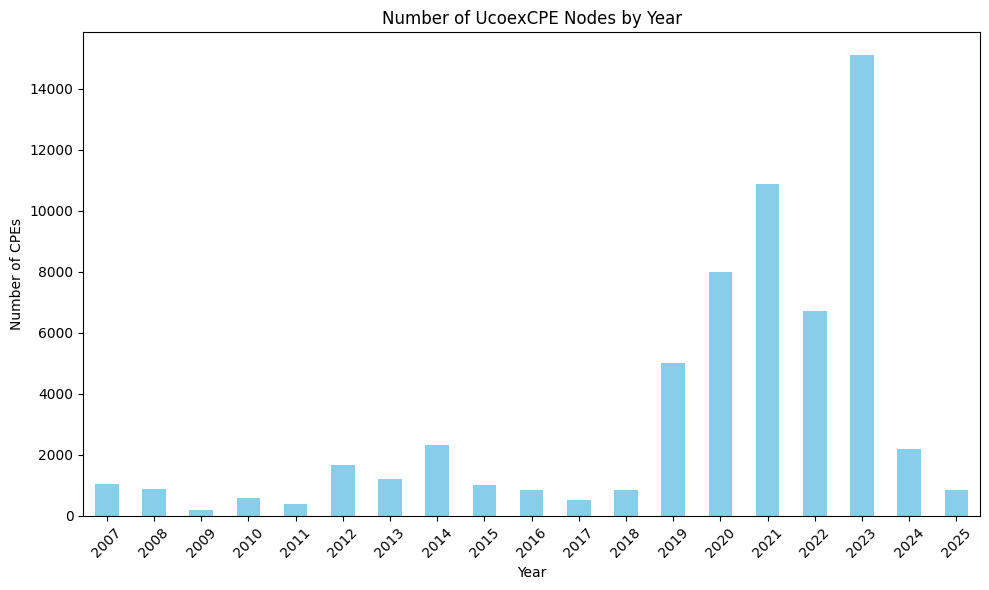

In [ ]:
query = """
MATCH (c:UcoexCPE)
WHERE c.lastModified IS NOT NULL
RETURN date(datetime(c.lastModified)).year AS Year, count(c) AS Count
ORDER BY Year
"""
records = run_query(query)

df_time_analysis = pd.DataFrame(records)

df_time_analysis.columns = ['Year', 'Count']
df_time_analysis.plot(x='Year', y='Count', kind='bar', figsize=(10, 6), color='skyblue', legend=False)
plt.xlabel('Year')
plt.ylabel('Number of CPEs')
plt.title('Number of UcoexCPE Nodes by Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---

## Conclusion

In this report, we explored the Common Platform Enumeration (CPE) dataset using a Neo4j graph database and Python. Below are the key takeaways:

1. **CPE Nodes and Relationships**:
    - The dataset contains a total of **135,417 CPE nodes** and **638,904 relationships**.
    - Relationships were analyzed by direction, showing a significant number of relationships pointing to CPE nodes.

2. **Node Properties**:
    - Added key properties of CPE nodes such as `cpeName`, `cpeNameId`, `dictionary_found`, `lastModified` and `titles`. These properties provide essential metadata for identifying and categorizing CPE entries.

3. **CPE Distribution**:
    - The distribution of CPEs by year revealed a steady increase in the number of entries, with a peak in recent years.
    - Product-specific analysis highlighted **Microsoft**, **Google**, and **Oracle** as the top vendors with the most CPE entries.

4. **CPE-CVE Relationships**:
    - Relationships between CPE and CVE nodes were analyzed, showing the interconnectedness of vulnerabilities with specific products.
    - Microsoft-related CPEs had the highest number of associated CVEs, emphasizing the importance of monitoring vulnerabilities for widely used products.

This analysis provides valuable insights into the structure and distribution of CPE data, helping organizations identify and manage vulnerabilities associated with their IT assets. Future work could involve deeper analysis of CVE data and its impact on specific industries or products.